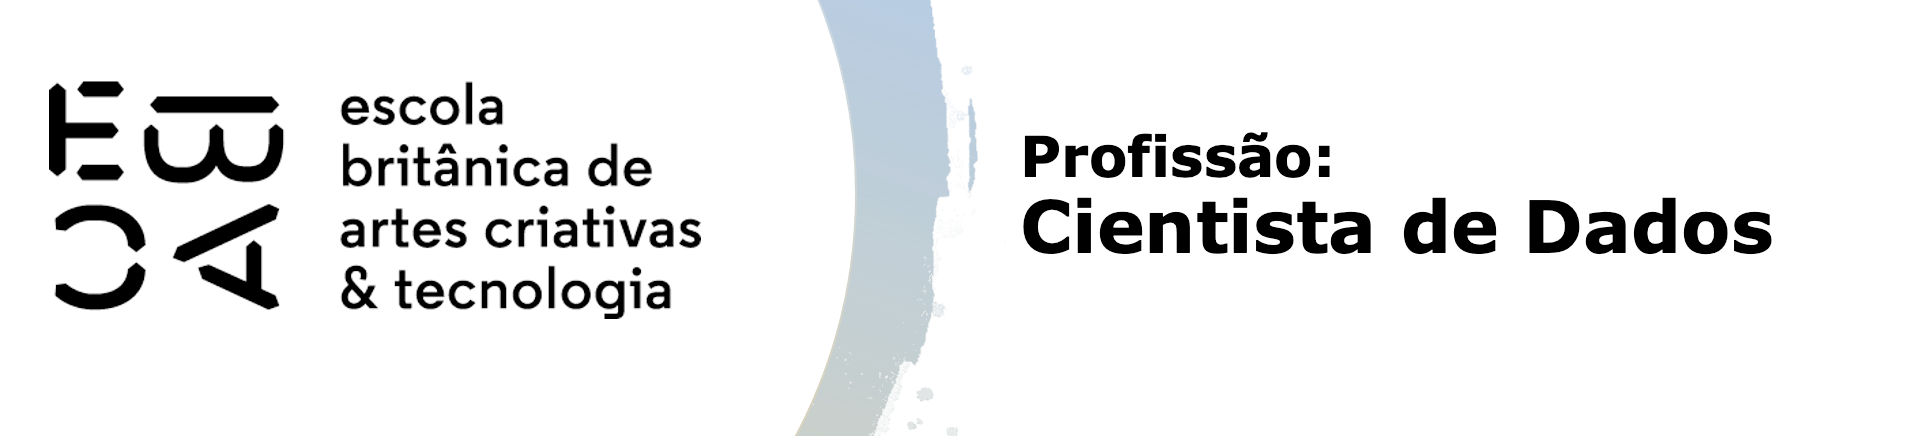

# Tarefa II

Ainda sobre a base da NFP vista na tarefa passada:

|Campo|Descrição|
|:-|:-|
|CNPJ emit.| CNPJ do emitente da nota|
|Emitente| Nome fantasia do emitente da nota|
|No.| Número da nota fiscal|
|Data Emissão| Data de emissão da nota fiscal|
|Valor NF| Valor da nota fiscal|
|Data Registro| Data de registro no sistema da NFP|
|Créditos| Valor dos créditos (doação)|
|Situação do Crédito| Se o crédito já foi pago, está sendo processado etc.|
|Ano| Ano da emissão da nota|
|Semestre| Semestre da emissão da nota|
|Retorno| Valor do crédito dividido pelo valor da nota|
|flag_credito| Indicadora se a nota possui crédito positivo|
|categoria| Categorização da nota |

**OBJETIVO:** Algumas notas não dão retorno, o que pode ocorrer por diversos motivos, um deles seria a ocorrência de produtos não incentivados como cigarros e bebidas alcólicas. O nosso objetivo é tentar prever que tipo de nota tem maior ou menor propensão a fornecer créditos.

**Observação**: Esta é uma base real, havendo características de acordo. Pode haver uma variabilidade difícil de explicar, em parte por causa de uma freqüência de notas inconstante no tempo (por diversos motivos), em parte por haverem informações importantes, protegidas pela LGPD, não constantes na base, que pode interferir no crédito gerado, o que vai ocasionar uma variabilidade difícil de se explicar. *Welcome to the jungle*, A vida real é assim :)

In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_pickle("base_nfp.pkl")
df_editavel = df.copy()

In [214]:
def IV(variavel, resposta):
    tab = pd.crosstab(variavel, resposta, margins=True, margins_name="total")

    rótulo_evento = tab.columns[0]
    rótulo_nao_evento = tab.columns[1]

    tab["pct_evento"] = tab[rótulo_evento] / tab.loc["total", rótulo_evento]
    tab["pct_nao_evento"] = tab[rótulo_nao_evento] / tab.loc["total", rótulo_nao_evento]
    tab["woe"] = np.log(
        tab.pct_evento.replace(0, 1e-6) / tab.pct_nao_evento.replace(0, 1e-6)
    )

    tab["iv_parcial"] = (tab.pct_evento - tab.pct_nao_evento) * tab.woe
    return tab["iv_parcial"].sum()

## Criando variáveis

**Variáveis temporais**: É possível que haja alguma regra de liberação de créditos de acordo com o dia do mês, o dia da semana, fim de semana (sim ou não), ou até alterações temporais da regra. Vamos criar as seguintes variáveis para testar estas hipóteses:

- Dia da semana
- Dummy para fim de semana
- Dia do mês
- Mês (já na base)
- Trimestre
- Ano (já na base)

**Valor da nota**: Vamos criar também algumas variáveis para resumir o valor da nota, e posteriormente criar uma intuição sobre categorizações de variáveis contínuas.

- Crie categorizações da variável ```Valor NF```, por quantís, em 5, 10, 20 e 50 categorias.

In [215]:
# Dicionário para mapear números dos meses para nomes em português
dicionario_de_meses = {
    "01": "Janeiro",
    "02": "Fevereiro",
    "03": "Março",
    "04": "Abril",
    "05": "Maio",
    "06": "Junho",
    "07": "Julho",
    "08": "Agosto",
    "09": "Setembro",
    "10": "Outubro",
    "11": "Novembro",
    "12": "Dezembro",
}

# Extrai o número do mês da coluna 'Data Registro' (convertida para string)
# O código [5] + [6] pega o 6º e 7º caracteres da string, que correspondem ao mês no formato 'YYYY-MM-DD'
df_editavel["Mês"] = [x[5] + x[6] for x in df_editavel["Data Registro"].astype("str")]

# Mapeia o número do mês para o nome do mês usando o dicionário criado
df_editavel["Mês"] = df_editavel["Mês"].map(dicionario_de_meses)

# Converte a coluna 'Data Registro' para o tipo datetime, caso ainda não esteja nesse formato
df_editavel["Data Registro"] = pd.to_datetime(df_editavel["Data Registro"])

# Cria uma nova coluna com o nome do dia da semana em português, extraído de 'Data Registro'
df_editavel["Dia da semana"] = df_editavel["Data Registro"].dt.day_name(locale="pt_BR")

# Cria uma nova coluna com o nome do dia do mês, extraído de 'Data Registro'
df_editavel["Dia do mês"] = df_editavel["Data Registro"].dt.day

# Cria uma nova coluna com o nome do Trimestre dividindo os meses do ano
df_editavel['Ano_Trimestre'] = df['Data Emissão'].dt.to_period('Q').apply(lambda x: f"{x.year}-T{x.quarter}")

df_editavel['Ano'] = df['Data Emissão'].dt.year


# Cria uma coluna indicando se o dia é fim de semana (sábado=5 ou domingo=6); 1 para sim, 0 para não
df_editavel["Fim de semana"] = (
    df_editavel["Data Registro"].dt.weekday.isin([5, 6]).astype(int)
)

# Exibe o dataframe resultante
df_editavel

,CNPJ emit.,Emitente,No.,Data Emissão,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,Retorno,flag_credito,categoria,Mês,Dia da semana,Dia do mês,Ano_Trimestre,Fim de semana
0,03.476.811/0741-98,DIA BRASIL SOCIEDADE LIMITADA,537,2017-06-30,24.68,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Mercado,Junho,Sexta-feira,30,2017-T2,0
1,43.101.310/0001-05,AUTO POSTO ZANWAL LTDA EPP,2894,2017-06-30,50.00,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Auto posto,Junho,Sexta-feira,30,2017-T2,0
2,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,699,2017-06-30,27.00,2017-06-30,0.44,Liberado,2017,1,0.016296,1,Restaurantes,Junho,Sexta-feira,30,2017-T2,0
3,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,698,2017-06-30,111.50,2017-06-30,1.81,Liberado,2017,1,0.016233,1,Restaurantes,Junho,Sexta-feira,30,2017-T2,0
4,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,694,2017-06-30,125.00,2017-06-30,2.03,Liberado,2017,1,0.016240,1,Restaurantes,Junho,Sexta-feira,30,2017-T2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187641,22.172.203/0004-40,B.BLEND MAQUINAS E BEBIDAS S. A.,180264,2021-01-07,252.84,2021-01-07,0.00,Liberado,2021,2,0.000000,0,não definido,Janeiro,Quinta-feira,7,2021-T1,0
187642,71.676.316/0005-70,SUPERMERCADOS MAMBO LTDA.,348953,2021-01-07,373.65,2021-01-07,0.00,Liberado,2021,2,0.000000,0,Mercado,Janeiro,Quinta-feira,7,2021-T1,0
187643,61.585.865/0240-93,RAIADROGASIL S/A,190447,2021-01-07,130.71,2021-01-07,0.00,Liberado,2021,2,0.000000,0,Farmácia,Janeiro,Quinta-feira,7,2021-T1,0
187644,67.616.128/0001-55,AYUMI SUPERMERCADOS LTDA - 1,51004,2021-01-07,43.16,2021-01-07,0.00,Liberado,2021,2,0.000000,0,Mercado,Janeiro,Quinta-feira,7,2021-T1,0


In [216]:
valor_cinco_quantis = pd.qcut(df_editavel["Valor NF"], 5)
valor_dez_quantis = pd.qcut(df_editavel["Valor NF"], 10)
valor_vinte_quantis = pd.qcut(df_editavel["Valor NF"], 20)
valor_cinquenta_quantis = pd.qcut(df_editavel["Valor NF"], 50)

## Calcule o IV de todas essas variáveis

Sugestão: Construa um metadados e tente utilizar uma função como a que foi utilizada durante a aula. Você vai conseguir fazer esse cálculo para as variáveis uma a uma, mas em casos reais em que vamos mais além na criação de variáveis, podemos ter centenas, ou até milhares de variáveis, esses cálculos *precisam* ser automáticos nesses casos.

In [217]:
valores_iv = {}


metadados = pd.DataFrame(df_editavel.dtypes)
metadados["papel"] = "covariavel"
metadados.loc["flag_credito", "papel"] = "resposta"
metadados["nunique"] = df_editavel.nunique()


for variavel in metadados.index.to_list():
    if variavel not in ["flag_credito"]:
        iv = IV(df_editavel[variavel], df_editavel["flag_credito"])
        valores_iv[variavel] = iv

df_iv = pd.DataFrame.from_dict(valores_iv, orient="index", columns=["IV"])
df_iv = df_iv.sort_values(by="IV", ascending=False)

metadados = metadados.join(df_iv["IV"])
metadados["Classificação IV"] = metadados.IV.map(
    lambda x: (
        "Inútil"
        if x <= 0.02
        else (
            "Fraco"
            if x <= 0.1
            else (
                "Médio" if x <= 0.3 else "Forte" if x <= 0.5 else "Suspeito de tão alto"
            )
        )
    )
)
metadados

,0,papel,nunique,IV,Classificação IV
CNPJ emit.,object,covariavel,19606,6.921201,Suspeito de tão alto
Emitente,object,covariavel,15575,6.944522,Suspeito de tão alto
No.,int64,covariavel,124400,3.385150,Suspeito de tão alto
Data Emissão,datetime64[ns],covariavel,1815,0.492227,Forte
Valor NF,float64,covariavel,33658,1.292439,Suspeito de tão alto
Data Registro,datetime64[ns],covariavel,1817,0.968882,Suspeito de tão alto
Créditos,float64,covariavel,9717,20.772279,Suspeito de tão alto
Situação do Crédito,category,covariavel,3,0.000866,Inútil
Ano,int32,covariavel,5,0.041761,Fraco
Semestre,int64,covariavel,2,0.001258,Inútil


In [218]:
def plot_iv_comparativo_estatico(metadados):
    """
    Plota o IV de todas as variáveis do dataframe 'metadados' como gráfico de barras ordenado.
    """
    df_plot = metadados.dropna(subset=["IV"]).sort_values("IV", ascending=False)

    # Corrigido: convertendo para lista
    cores = (
        df_plot["IV"]
        .apply(
            lambda x: (
                "grey"
                if x < 0.02
                else (
                    "orange"
                    if x < 0.1
                    else "green" if x < 0.3 else "blue" if x < 0.5 else "purple"
                )
            )
        )
        .tolist()
    )

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(y=df_plot.index, x="IV", data=df_plot, palette=cores)

    plt.axvline(0.02, color="grey", linestyle="--", lw=1)
    plt.axvline(0.1, color="orange", linestyle="--", lw=1)
    plt.axvline(0.3, color="green", linestyle="--", lw=1)
    plt.axvline(0.5, color="blue", linestyle="--", lw=1)

    plt.title("Information Value por variável", fontsize=16)
    plt.xlabel("IV")
    plt.ylabel("Variável")
    plt.legend()
    plt.grid(True, axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

C:\Users\hfasa\AppData\Local\Temp\ipykernel_25020\3136926174.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=df_plot.index, x="IV", data=df_plot, palette=cores)
C:\Users\hfasa\AppData\Local\Temp\ipykernel_25020\3136926174.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


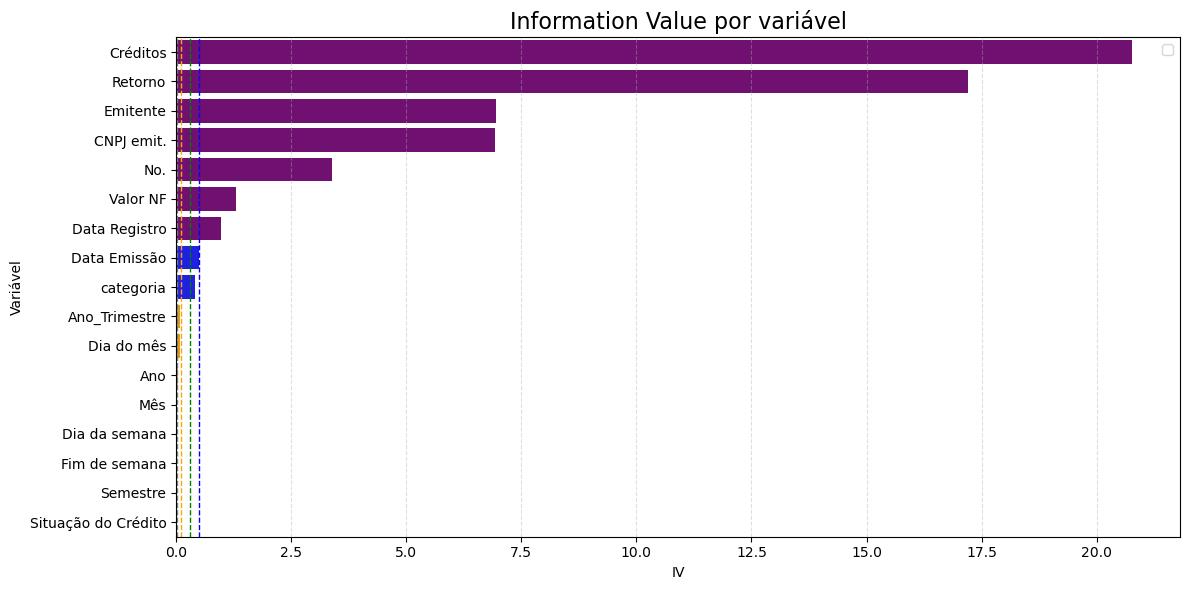

In [219]:
plot_iv_comparativo_estatico(metadados)

## Conclua

- Quais variáveis parecem apresentar maior poder de discriminação segundo o IV?
- Quando categorizamos variáveis contínuas parece haver alguma relação entre o número de categorias e o IV?

In [220]:
metadados.loc[metadados["Classificação IV"] == "Forte"]

,0,papel,nunique,IV,Classificação IV
Data Emissão,datetime64[ns],covariavel,1815,0.492227,Forte
categoria,object,covariavel,9,0.408313,Forte


<font color='#6A5ACD'>**Conclusão:** Utilizei a célula acima como um recurso visual para apoiar a explicação. Apenas duas variáveis apresentaram um Information Value considerado forte: "Data de Emissão" e "categoria". Variáveis derivadas da "Data de Emissão", como "Dia da Semana" e "Mês", demonstraram desempenho irrelevante. As demais variáveis ou apresentam valores de IV excessivamente altos, ou são fracas. Nenhuma delas se enquadra na faixa considerada de IV médio, portanto, podem ser descartadas na seleção de variáveis..</font>

## Descritiva simples no tempo

Para compor a análise que virá a seguir, faça uma análise descritiva básica no tempo - utilize trimestre como agregação (ou uma média móvel por trimestre, como preferir) e avalie graficamente:

- A quantidade de notas registradas na base por período
- A quantidade de notas por categoria e por período
- A proporção de notas com crédito por categoria por período

In [221]:
df_editavel

,CNPJ emit.,Emitente,No.,Data Emissão,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,Retorno,flag_credito,categoria,Mês,Dia da semana,Dia do mês,Ano_Trimestre,Fim de semana
0,03.476.811/0741-98,DIA BRASIL SOCIEDADE LIMITADA,537,2017-06-30,24.68,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Mercado,Junho,Sexta-feira,30,2017-T2,0
1,43.101.310/0001-05,AUTO POSTO ZANWAL LTDA EPP,2894,2017-06-30,50.00,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Auto posto,Junho,Sexta-feira,30,2017-T2,0
2,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,699,2017-06-30,27.00,2017-06-30,0.44,Liberado,2017,1,0.016296,1,Restaurantes,Junho,Sexta-feira,30,2017-T2,0
3,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,698,2017-06-30,111.50,2017-06-30,1.81,Liberado,2017,1,0.016233,1,Restaurantes,Junho,Sexta-feira,30,2017-T2,0
4,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,694,2017-06-30,125.00,2017-06-30,2.03,Liberado,2017,1,0.016240,1,Restaurantes,Junho,Sexta-feira,30,2017-T2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187641,22.172.203/0004-40,B.BLEND MAQUINAS E BEBIDAS S. A.,180264,2021-01-07,252.84,2021-01-07,0.00,Liberado,2021,2,0.000000,0,não definido,Janeiro,Quinta-feira,7,2021-T1,0
187642,71.676.316/0005-70,SUPERMERCADOS MAMBO LTDA.,348953,2021-01-07,373.65,2021-01-07,0.00,Liberado,2021,2,0.000000,0,Mercado,Janeiro,Quinta-feira,7,2021-T1,0
187643,61.585.865/0240-93,RAIADROGASIL S/A,190447,2021-01-07,130.71,2021-01-07,0.00,Liberado,2021,2,0.000000,0,Farmácia,Janeiro,Quinta-feira,7,2021-T1,0
187644,67.616.128/0001-55,AYUMI SUPERMERCADOS LTDA - 1,51004,2021-01-07,43.16,2021-01-07,0.00,Liberado,2021,2,0.000000,0,Mercado,Janeiro,Quinta-feira,7,2021-T1,0


In [222]:
totais_por_trimestre = df_editavel.groupby("Ano_Trimestre").count()
totais_por_trimestre["Nota"] = totais_por_trimestre["Emitente"]
totais_por_trimestre.drop(
    columns=[x for x in df_editavel.columns.to_list() if x not in ["Ano_Trimestre"]],
    inplace=True,
)
totais_por_trimestre

,Nota
Ano_Trimestre,
2017-T1,13418
2017-T2,11315
2017-T3,11162
2017-T4,7713
2018-T1,1160
2018-T2,1906
2018-T3,2482
2018-T4,4071
2019-T1,7196


In [223]:
df_editavel

,CNPJ emit.,Emitente,No.,Data Emissão,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,Retorno,flag_credito,categoria,Mês,Dia da semana,Dia do mês,Ano_Trimestre,Fim de semana
0,03.476.811/0741-98,DIA BRASIL SOCIEDADE LIMITADA,537,2017-06-30,24.68,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Mercado,Junho,Sexta-feira,30,2017-T2,0
1,43.101.310/0001-05,AUTO POSTO ZANWAL LTDA EPP,2894,2017-06-30,50.00,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Auto posto,Junho,Sexta-feira,30,2017-T2,0
2,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,699,2017-06-30,27.00,2017-06-30,0.44,Liberado,2017,1,0.016296,1,Restaurantes,Junho,Sexta-feira,30,2017-T2,0
3,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,698,2017-06-30,111.50,2017-06-30,1.81,Liberado,2017,1,0.016233,1,Restaurantes,Junho,Sexta-feira,30,2017-T2,0
4,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,694,2017-06-30,125.00,2017-06-30,2.03,Liberado,2017,1,0.016240,1,Restaurantes,Junho,Sexta-feira,30,2017-T2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187641,22.172.203/0004-40,B.BLEND MAQUINAS E BEBIDAS S. A.,180264,2021-01-07,252.84,2021-01-07,0.00,Liberado,2021,2,0.000000,0,não definido,Janeiro,Quinta-feira,7,2021-T1,0
187642,71.676.316/0005-70,SUPERMERCADOS MAMBO LTDA.,348953,2021-01-07,373.65,2021-01-07,0.00,Liberado,2021,2,0.000000,0,Mercado,Janeiro,Quinta-feira,7,2021-T1,0
187643,61.585.865/0240-93,RAIADROGASIL S/A,190447,2021-01-07,130.71,2021-01-07,0.00,Liberado,2021,2,0.000000,0,Farmácia,Janeiro,Quinta-feira,7,2021-T1,0
187644,67.616.128/0001-55,AYUMI SUPERMERCADOS LTDA - 1,51004,2021-01-07,43.16,2021-01-07,0.00,Liberado,2021,2,0.000000,0,Mercado,Janeiro,Quinta-feira,7,2021-T1,0


In [224]:
df_editavel['Quantidade de notas'] = 1
qtd_notas_trimestre = pd.crosstab(index=[df_editavel['Ano'], df_editavel['Ano_Trimestre'], df_editavel['categoria']], columns=df_editavel['Quantidade de notas'])
df_editavel.drop(columns=['Quantidade de notas'])
qtd_notas_trimestre = qtd_notas_trimestre.reset_index().rename(columns={1: 'Quantidade de Notas'})
qtd_notas_trimestre

Quantidade de notas,Ano,Ano_Trimestre,categoria,Quantidade de Notas
0,2017,2017-T1,Alimentos,1285
1,2017,2017-T1,Auto posto,744
2,2017,2017-T1,Construção,1410
3,2017,2017-T1,Farmácia,639
4,2017,2017-T1,Mercado,1344
...,...,...,...,...
175,2021,2021-T4,Mercado,3534
176,2021,2021-T4,Restaurantes,257
177,2021,2021-T4,Varejo,739
178,2021,2021-T4,Vestuário,338


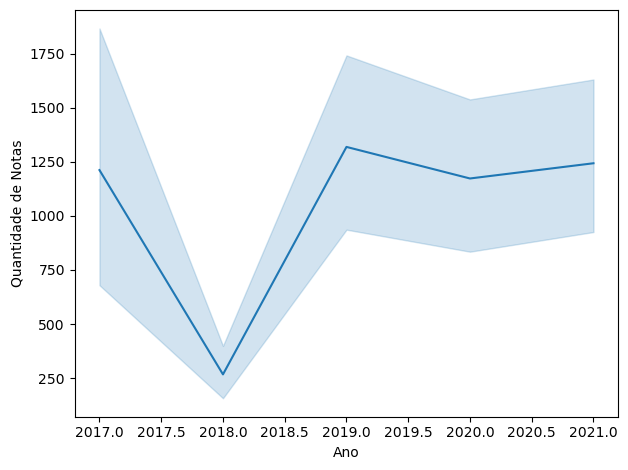

In [225]:
sns.lineplot(data=qtd_notas_trimestre, x=qtd_notas_trimestre["Ano"], y=qtd_notas_trimestre["Quantidade de Notas"])
plt.tight_layout()

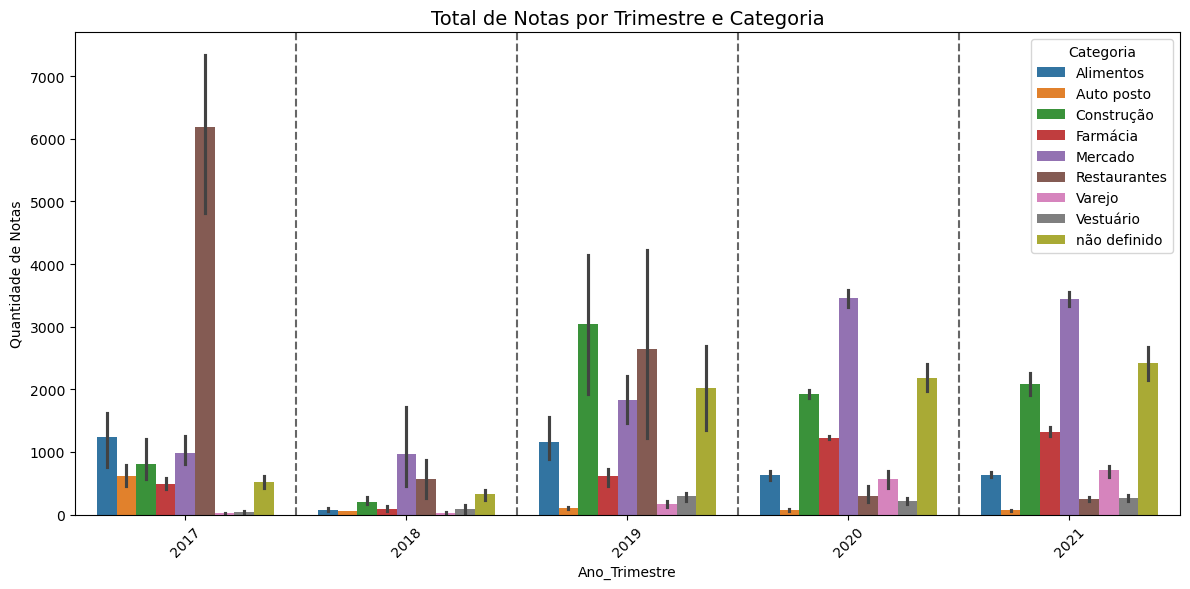

In [247]:
# Criação da figura e do eixo
fig, ax = plt.subplots(figsize=(12, 6))

# Gráfico de barras
sns.barplot(
    data=qtd_notas_trimestre, x=qtd_notas_trimestre['Ano'], y=qtd_notas_trimestre['Quantidade de Notas'], hue="categoria", ax=ax
)

# Obtém as posições dos ticks do eixo x (anos)
ticks = ax.get_xticks()
anos = df_editavel["Ano"].unique()

# Adiciona linhas verticais entre os anos para facilitar a visualização das separações temporais
for i in range(1, len(ticks)):
    pos = (ticks[i] + ticks[i - 1]) / 2
    ax.axvline(x=pos, linestyle="--", color="black", alpha=0.6)
    
# Título e ajustes visuais
ax.set_title("Total de Notas por Trimestre e Categoria", fontsize=14)
ax.set_ylabel("Quantidade de Notas")
ax.set_xlabel("Ano_Trimestre")
ax.legend(title="Categoria", loc="best")
ax.tick_params(axis="x", rotation=45)

# Layout final
plt.tight_layout()

## Avalie o WOE e o IV no tempo

Avalie o WOE e o IV no tempo da variável ```categoria```.

In [231]:
tab = pd.crosstab(
    index=[df_editavel["categoria"], df_editavel["Ano_Trimestre"], df_editavel['Ano']],
    columns=df_editavel["flag_credito"],
    margins=True,
    margins_name="Total",
)

rotulo_evento = tab[1]

rotulo_nao_evento = tab[0]
tab["pct_evento"] = rotulo_evento / tab["Total"]
tab["pct_nao_evento"] = rotulo_nao_evento / tab["Total"]
tab["chances_evento"] = rotulo_nao_evento / rotulo_evento
tab["WOE"] = np.log(tab.chances_evento)
tab["iv_parcial"] = (tab.pct_evento - tab.pct_nao_evento) * tab["WOE"]
tab

flag_credito                          0      1   Total  pct_evento  \
categoria    Ano_Trimestre Ano                                       
Alimentos    2017-T1       2017      17   1268    1285    0.986770   
             2017-T2       2017       9   1735    1744    0.994839   
             2017-T3       2017      34   1310    1344    0.974702   
             2017-T4       2017      11    562     573    0.980803   
             2018-T1       2018      13     31      44    0.704545   
...                                 ...    ...     ...         ...   
não definido 2021-T1       2021    1301    778    2079    0.374218   
             2021-T2       2021    1495    723    2218    0.325969   
             2021-T3       2021    1664    875    2539    0.344624   
             2021-T4       2021    1872    952    2824    0.337110   
Total                            103008  84638  187646    0.451051   

flag_credito                     pct_nao_evento  chances_evento       WOE  \
categoria    Ano_Trimestre Ano                                              
Alimentos    2017-T1       2017        0.013230        0.013407 -4.311983   
             2017-T2       2017        0.005161        0.005187 -5.261538   
             2017-T3       2017        0.025298        0.025954 -3.651422   
             2017-T4       2017        0.019197        0.019573 -3.933607   
             2018-T1       2018        0.295455        0.419355 -0.869038   
...                                         ...             ...       ...   
não definido 2021-T1       2021        0.625782        1.672237  0.514162   
             2021-T2       2021        0.674031        2.067773  0.726472   
             2021-T3       2021        0.655376        1.901714  0.642756   
             2021-T4       2021        0.662890        1.966387  0.676198   
Total                                  0.548949        1.217042  0.196423   

flag_credito                     iv_parcial  
categoria    Ano_Trimestre Ano               
Alimentos    2017-T1       2017   -4.197891  
             2017-T2       2017   -5.207233  
             2017-T3       2017   -3.466677  
             2017-T4       2017   -3.782578  
             2018-T1       2018   -0.355515  
...                                     ...  
não definido 2021-T1       2021   -0.129344  
             2021-T2       2021   -0.252857  
             2021-T3       2021   -0.199738  
             2021-T4       2021   -0.220291  
Total                             -0.019229  

[181 rows x 8 columns]

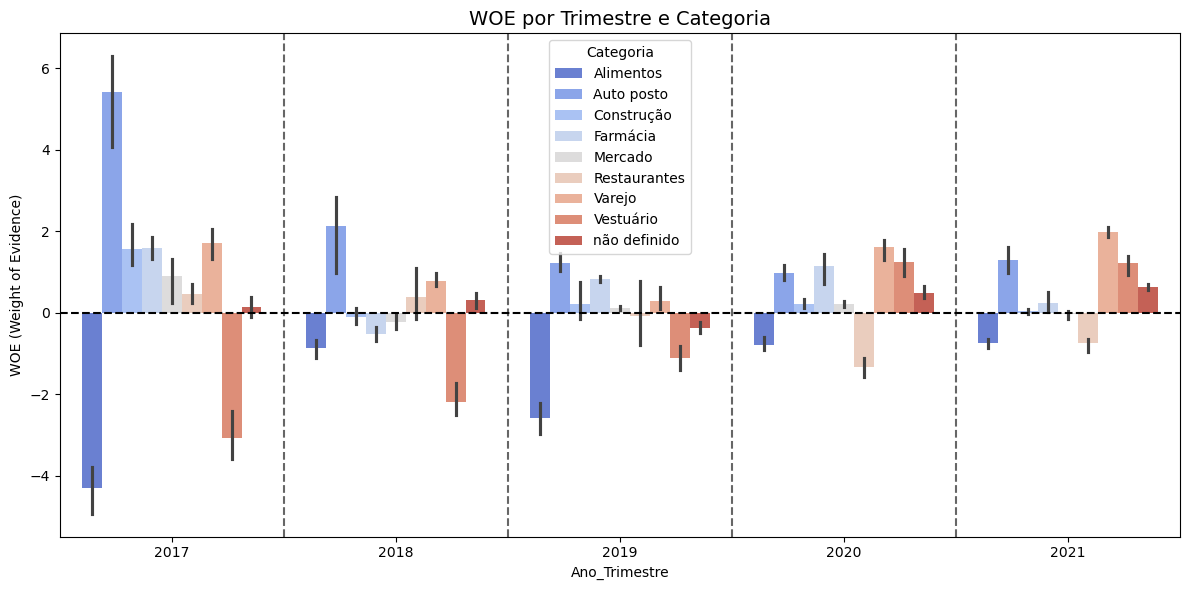

In [246]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=tab.loc[tab.index.get_level_values(0) != "Total"].reset_index(),
    x="Ano",
    y="WOE",
    hue="categoria",
    ax=ax,
    palette="coolwarm",
)

# Obtém as posições dos ticks do eixo x (anos)
ticks = ax.get_xticks()
anos = df_editavel["Ano"].unique()

# Adiciona linhas verticais entre os anos para facilitar a visualização das separações temporais
for i in range(1, len(ticks)):
    pos = (ticks[i] + ticks[i - 1]) / 2
    ax.axvline(x=pos, linestyle="--", color="black", alpha=0.6)

# Ajustes visuais
ax.set_title("WOE por Trimestre e Categoria", fontsize=14)
ax.set_ylabel("WOE (Weight of Evidence)")
ax.set_xlabel("Ano_Trimestre")
ax.legend(title="Categoria", loc="best")
ax.tick_params(axis="x", rotation=0)
ax.axhline(0, linestyle="--", color="black")

plt.tight_layout()
plt.show()

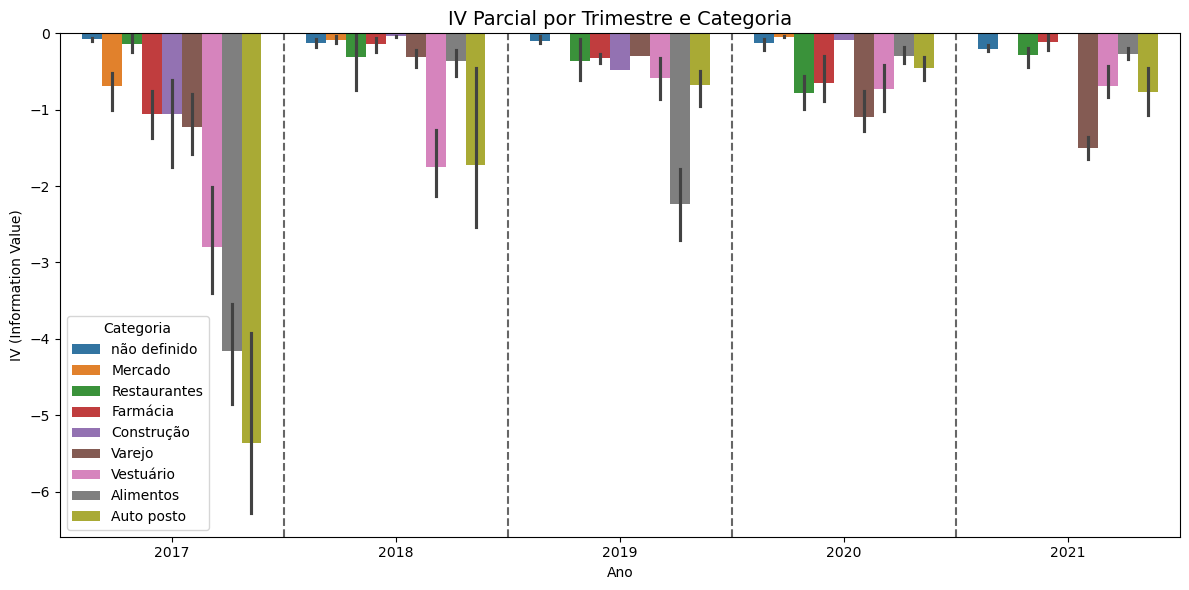

In [ ]:
# Filtra o DataFrame tab para remover linhas de totais e mantém apenas linhas com IV parcial relevante (>0.02)
df_plot = tab.loc[
    (tab.index.get_level_values(0) != "Total") & ((tab["iv_parcial"].abs() > 0.02))
].reset_index()

# Ordena os dados por ano para garantir que o eixo x fique na ordem correta
df_plot = df_plot.sort_values("Ano")

# Calcula a ordem das categorias com base no IV médio, para que as cores do gráfico fiquem ordenadas por relevância
ordem_categorias = (
    df_plot.groupby("categoria")["iv_parcial"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# Cria a figura e o eixo para o gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Plota o gráfico de barras do IV parcial por ano, separado por categoria
sns.barplot(
    data=df_plot,
    x="Ano",
    y="iv_parcial",
    hue="categoria",
    hue_order=ordem_categorias,
    ax=ax,
)

# Obtém as posições dos ticks do eixo x (anos)
ticks = ax.get_xticks()
anos = df_plot["Ano"].unique()

# Adiciona linhas verticais entre os anos para facilitar a visualização das separações temporais
for i in range(1, len(ticks)):
    pos = (ticks[i] + ticks[i - 1]) / 2
    ax.axvline(x=pos, linestyle="--", color="black", alpha=0.6)

# Ajusta os títulos e rótulos do gráfico
ax.set_title("IV Parcial por Trimestre e Categoria", fontsize=14)
ax.set_ylabel("IV (Information Value)")
ax.set_xlabel("Ano")
ax.legend(title="Categoria", loc="best")
ax.tick_params(axis="x", rotation=0)

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.show()


In [230]:
tab["iv_parcial"].sum()

-inf

## Conclua

- Quais categorias parece ter maior proporção de notas com retornos maiores que zero?
- Essas diferenças são estáveis no tempo?

Dicas:<br>
- Considere que a quantidade de notas vem aumentando
- Considere que há períodos bem atípicos no histórico
- Considere que a partir de janeiro de 2020 o público é mais parecido com o público atual (2022), seja por pandemia, seja por crescimento do público, e considere os dados dessa data em diante na sua conclusão.

<font color='#6A5ACD'>**Conclusão:** De acordo com as análises, a categoria de Construção demonstra retornos positivos de forma consistente, embora nem sempre com valores expressivos. O mesmo padrão é observado nas categorias de Varejo e Auto Posto, que também apresentam desempenho positivo recorrente. Apesar disso, esses setores, em geral, não possuem alto volume de notas — com exceção da categoria de Construção, que teve um aumento significativo nos últimos três anos.</font>